# Table of contents

* **Introduction**
* **Objective**
* **Perceptron Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training and Experiments**
    * Model Architecture, Model Building, and Model Training (PyTorch)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The Perceptron, introduced in the 1950s, is the fundamental concept underpinning modern neural networks. It is a single-layer, single-neuron linear classifier that determines a decision boundary to separate two classes. While contemporary deep learning frequently involves complex architectures, implementing the simple Perceptron using a powerful framework like PyTorch is an invaluable educational exercise. This approach demonstrates explicit control over the core mechanics of gradient-based learning: the forward pass, loss calculation, backpropagation, and parameter optimization. The project applies this minimal model to a real-world malware detection task, utilizing 100 features derived from dynamic API call sequences to classify programs as either benign (Class 0) or malicious (Class 1).

# Objective

The primary goals of this project are strictly educational and demonstrative:

- To implement the classic Perceptron using PyTorch’s lower-level primitives (`nn.Module, torch.optim`, manual training loop).
- To explicitly demonstrate the core process of machine learning model training using a low-level framework, including gradient computation and explicit parameter updates.
- To establish that a PyTorch architecture comprising one `nn.Linear(2, 1)` layer followed by a Sigmoid activation is mathematically equivalent to both logistic regression and the original, threshold-based Perceptron (when thresholded).
- To visualize the model's learned linear decision boundary within a 2D feature space to provide clear interpretability.

# Perceptron Foundations

The Perceptron is the simplest form of an artificial neural network, representing a linear binary classifier. Developed by Frank Rosenblatt in 1957, it models a single neuron's ability to make a decision by combining input features.

**Core Architecture and Function**

The Perceptron operates by taking a set of inputs, processing them through a weighted sum, and then passing the result through an activation function to produce an output.

1. Input and Weights: An input vector $x = [x_1, x_2, \ldots, x_n]$ is received, corresponding to the feature values of a sample. Each input is associated with a synaptic weight vector $w = [w_1, w_2, \ldots, w_n]$, which determines the importance of the corresponding input feature. A bias term, $b$, is also included, which can be thought of as an extra input with a fixed value of 1.

2. Net Input Function: The first step is the computation of the net input, $z$. This calculation is the sum of the weighted inputs plus the bias term, representing a linear combination of the input features. This is mathematically expressed as the dot product of the input vector and the weight vector, plus the bias:

$$z = \sum_{i=1}^{n} (x_i w_i) + b = w^T x + b$$

3. Activation Function: The net input $z$ is then fed into an activation function, $f(z)$, to determine the output (the prediction). The classical Perceptron uses the Heaviside step function (or sign function) as its activation function. This function returns 1 if the net input is positive or zero, and 0 (or -1, depending on the convention) if the net input is negative. The output prediction $\hat{y}$ is:

$$\hat{y} = f(z) = \begin{cases} 1 & \text{if } w^T x + b \ge 0 \\ 0 & \text{if } w^T x + b < 0 \end{cases}$$

**The Learning Mechanism: Perceptron Learning Rule**

The learning process is an iterative, supervised approach designed to minimize classification errors. The Perceptron learning rule is a modification rule that updates the weights only when a misclassification occurs.

- Goal: To find a set of weights $w$ and a bias $b$ that correctly separates the two classes.
- Initialization: Weights and bias are typically initialized to small random values or zero.
- Update Rule: For each training sample $(x^{(j)}, y^{(j)})$ where a misclassification occurs (i.e., $y^{(j)} \ne \hat{y}^{(j)}$):
    - The weight vector is updated according to the following formula:$$w^{(t+1)} = w^{(t)} + \Delta w$$where the change in weights $\Delta w$ is:$$\Delta w = \eta (y^{(j)} - \hat{y}^{(j)}) x^{(j)}$$
      $\eta$ (eta) is the learning rate, a hyperparameter controlling the magnitude of the weight adjustments. A smaller $\eta$ leads to slower but potentially more stable convergence.
      $y^{(j)}$ is the true class label (target).
      $\hat{y}^{(j)}$ is the predicted class label (output).
      $(y^{(j)} - \hat{y}^{(j)})$ is the error, which can only be $-1$, $0$, or $1$.

**Mechanism of Update:**

- If the prediction is too high ($\hat{y}=1$ and $y=0$): $w$ is moved away from $x^{(j)}$.
- If the prediction is too low ($\hat{y}=0$ and $y=1$): $w$ is moved toward $x^{(j)}$.
- If the prediction is correct, the weights remain unchanged ($\Delta w = 0$).

The bias is updated similarly:


$$\Delta b = \eta (y^{(j)} - \hat{y}^{(j)})$$

This iterative process continues for a fixed number of epochs or until a stopping criterion is met.

**Linear Separability Constraint**

The most significant theoretical constraint of the Perceptron is its requirement for linear separability.
- Concept: The Perceptron can only perfectly classify data if the two classes can be separated by a single straight line (in 2D), a plane (in 3D), or a hyperplane (in higher dimensions). The vector $w$ defines the normal to this decision boundary hyperplane.
- Perceptron Convergence Theorem: This theorem states that if and only if the training data is linearly separable, the Perceptron algorithm is guaranteed to find a solution (a separating hyperplane) in a finite number of steps.
- Limitation: The inability of a single-layer Perceptron to solve non-linearly separable problems (famously demonstrated by the XOR problem) led to a temporary decline in neural network research until the development of multi-layer networks, which employ hidden layers and non-linear activation functions to overcome this limitation.

**Practical Considerations**

- Feature Scaling: Prior to training, it is crucial to standardize or normalize the input features. Features on different scales can cause the Perceptron's weight updates to be disproportionate, leading to slower convergence or oscillation. Techniques like $Z$-score standardization or min-max scaling ensure all features contribute equally to the distance calculation.
- Overfitting: The Perceptron does not inherently possess regularization mechanisms. While it converges if the data is linearly separable, for real-world, non-separable data, the algorithm may never fully converge, resulting in weights that oscillate. Training for too many epochs on separable data can also lead to overfitting if the data contains outliers or noise.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The project workflow is designed to be systematic, reproducible, and compliant with best practices for deep learning projects:
- Data Preparation: Load the dataset and analyze the initial class distribution.
- Preprocessing: Standardize features and reduce dimensionality using PCA.
- Imbalance Mitigation: Apply SMOTE exclusively to the training subset.
- Data Conversion: Transform processed NumPy arrays into PyTorch tensors.
- Model Definition: Define the single-neuron Perceptron using the nn.Module class.
- Training & Optimization: Execute the manual training loop incorporating early stopping and saving of the best model state.
- Visualization: Generate plots for training history (loss and accuracy) and the final decision boundary.
- Evaluation: Compute and report standard classification metrics on the untouched test set.

# Approach

**Preprocessing Pipeline Approach**

A rigorous, leakage-free preprocessing methodology is followed to ensure unbiased model evaluation and provide a low-dimensional space for visualization.
- Feature Scaling: The StandardScaler is fitted solely on the training data. This process transforms the 100 raw features to have a mean of 0 and a standard deviation of 1. The calculated scaling parameters are then applied to both the training and test sets, preventing data leakage from the test distribution.
- Dimensionality Reduction: Principal Component Analysis (PCA) is applied to the scaled training features. The dimensionality is reduced from 100 features down to `n_components=2`. PCA captures the maximum variance in the original data, projecting it into a 2D space suitable for visualizing the data clusters and the Perceptron's decision boundary.
- Class Imbalance Handling: The Synthetic Minority Over-sampling Technique (SMOTE) is applied only to the PCA-reduced training set. SMOTE synthesizes new data points for the minority class (benign), creating a perfectly balanced 50:50 class ratio for robust training. The test set remains imbalanced to simulate real-world, skewed performance assessment.
- Tensor Conversion: The final, processed NumPy arrays are converted into `torch.float32` tensors, the required data structure for PyTorch model operations.

**Model Training Approach**

The Perceptron is implemented as a custom PyTorch class extending nn.Module, providing full transparency into the model's structure and operations.

- Architecture: The model consists of one `nn.Linear` layer (input dimension of 2, output dimension of 1) followed by an `nn.Sigmoid` activation function. This configuration represents the single-neuron structure.
- Training Components:
    - Loss Function: Binary Cross-Entropy Loss (`nn.BCELoss`) is utilized, which is appropriate for measuring the difference between predicted probabilities (from the Sigmoid output) and true binary labels.
    - Optimizer: The Adam optimizer is chosen for its adaptive learning rate capabilities, efficiently driving the model to minimize the loss.
    - Training Loop: A full manual training loop is executed. This includes setting the model to `train()` mode, performing the forward pass, calculating the loss, zeroing the gradients, executing the backward pass (`loss.backward()`), and updating parameters (`optimizer.step()`).
- Regularization: The training incorporates a validation split (20%) and early stopping, which monitors the validation loss and restores the weights from the best-performing epoch to mitigate overfitting.

**Model Evaluation Approach**

Comprehensive evaluation is performed on the completely untouched, imbalanced test set, leveraging the probabilistic output of the Sigmoid activation.
- Prediction: Predictions are generated in `model.eval()` mode under `torch.no_grad()` to ensure stability and efficiency. Output probabilities are converted to binary predictions using a 0.5 threshold.
- Metric Assessment: Performance is measured across several dimensions to provide a complete picture of the classifier’s strengths and weaknesses, particularly concerning the imbalanced classes:
    - Accuracy, Precision, Recall, and F1-score (macro-averaged).
    - ROC-AUC (Area Under the Receiver Operating Characteristic Curve). 
    - Precision-Recall Curve.
- Visualization: The final learned weights and bias are used to plot the linear decision boundary on the PCA-reduced feature space. The raw test data points are overlaid on the decision regions to visually assess the model's generalization capability and the effects of class overlap.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install imblearn            
!pip install imbalanced-learn==0.10.1 
!pip install --upgrade imbalanced-learn 

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve
)

import imblearn
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim

import os

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.6.0+cu124


**Data Loading**

The process begins with loading the malware API call sequence dataset. The dataset comprises numerical features representing 100 consecutive API calls (`t_0` through `t_99`) and a target variable, malware, which is the binary classification label. A unique identifier column, hash, is immediately removed as it holds no predictive value for the model. Instances with missing values (NaN) are dropped to ensure data quality and model stability. The dataset size after cleaning is 43,876 samples with 101 columns (100 features + 1 target).

In [5]:
# reading data
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Cleaning**

In [6]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Train and Test Split**

The dataset is partitioned into training and testing subsets using the train-test split methodology. This step is crucial for establishing the generalization capability of any machine learning model.

- Training Set (80%): Used by the model to learn the patterns and parameters (weights and bias).
- Testing Set (20%): Held out and completely sequestered from the training process. This set provides an unbiased estimate of the model's performance on unseen data.

By setting a fixed random_state, the split is made reproducible, ensuring that the same division of data is used across all experiments. The resulting training set contains 35,100 samples, and the test set contains 8,776 samples.

In [7]:
# Split the data into training and testing sets
train, test = train_test_split(df, test_size=0.2, random_state=42) 

# Print the shapes of the resulting sets
print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

A preliminary review of the feature statistics and data types confirms that all 100 features (`t_0` to `t_99`) are numerical (`int64`), representing encoded API calls. No further missing values are found in the split datasets. The descriptive statistics reveal that feature values span a wide range, indicating a need for feature scaling (normalization or standardization) later in the preprocessing pipeline to prevent features with larger magnitudes from dominating the learning process.

**Basic Statistics**

In [8]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [9]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [11]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [12]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Target Labels Distribution**

The most critical finding from the initial data analysis is the severe class imbalance in the target variable, malware.

Class Imbalance: This refers to a scenario where the distribution of observations across the output classes is unequal, leading to a majority class and a minority class. This imbalance can bias a classifier towards the majority class, resulting in poor predictive performance for the minority class, often manifesting as high accuracy but low recall or precision for the critical class.

In [13]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

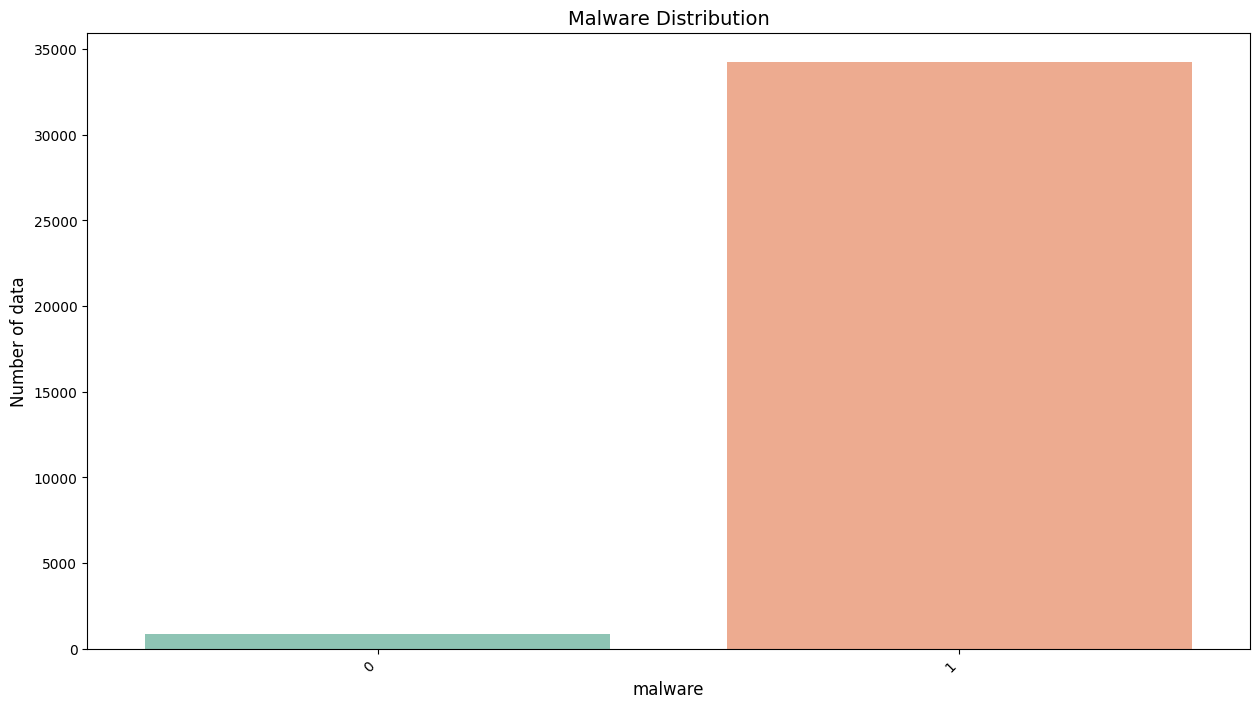

In [14]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
# Assign the barplot to an axes object 'ax'
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

**Interpretation of Results:**

The normalized value counts reveal the following distribution within the training data:

- Class 1 (malware): 97.57% (Majority Class)
- Class 0 (Benign): 2.43% (Minority Class)

The bar plot visually confirms this severe skew. The bar representing the majority class (malware) dwarfs the bar for the minority class (benign).

This extreme imbalance dictates that standard accuracy alone is an insufficient evaluation metric. Subsequent model development must incorporate techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class weighting to mitigate this bias and ensure the model can effectively detect the rare but critical minority class (benign or non-malware samples).

# Features Engineering

**Features and Target Labels Split**

The initial step in feature engineering involves cleanly separating the independent variables (features, $\mathbf{X}$) from the dependent variable (target, $y$). The 100 API call features (`t_0 to t_99`) constitute the feature matrix, while the malware column serves as the target vector. This separation is performed independently for the previously split training and testing datasets to maintain strict data integrity. The resulting training feature matrix (`X_train`) has a shape of `(35100, 100)`, and the corresponding target vector (`y_train`) has a shape of `(35100,)`.

In [ ]:
x_train = train.drop('malware', axis=1) 
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normalization (Standardization)**

Standardization, implemented using the StandardScaler, is a mandatory preprocessing step for many machine learning algorithms, especially those that rely on distance calculations, such as Neural Networks and PCA.

- Process: The standardization transforms the data such that each feature has a mean of 0 and a standard deviation of 1. The formula applied to each data point $x$ is: $$z = \frac{x - \mu}{\sigma}$$where $\mu$ is the mean and $\sigma$ is the standard deviation.
- Principle: This technique ensures that all features contribute equally to the distance calculation regardless of their original scale. Crucially, the scaler is fitted only on the training data (`X_train`), and those parameters ($\mu$ and $\sigma$) are then applied to transform both the training and test sets (`X_test`). This prevents data leakage from the test set into the training process.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

Principal Component Analysis (PCA) is a powerful linear transformation technique used for dimensionality reduction and data visualization.

- Process: PCA identifies the directions (principal components) in the high-dimensional feature space that account for the maximum variance in the data. The data is then projected onto these new, orthogonal axes. In this project, the dimensionality is reduced from 100 dimensions to `n_components=2`.
- Goal: The primary goal here is two-fold: to simplify the input space for the minimal Perceptron model and, more importantly, to enable the visualization of data clusters and the model's eventual decision boundary in a 2D plot.
- Application Integrity: PCA is fitted only on the standardized training data (`X_train_std`), and the resulting transformation matrices are used to transform both the training and testing sets.

In [ ]:
pca = PCA(n_components=2) 
x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

**Before Oversampling Visualization**

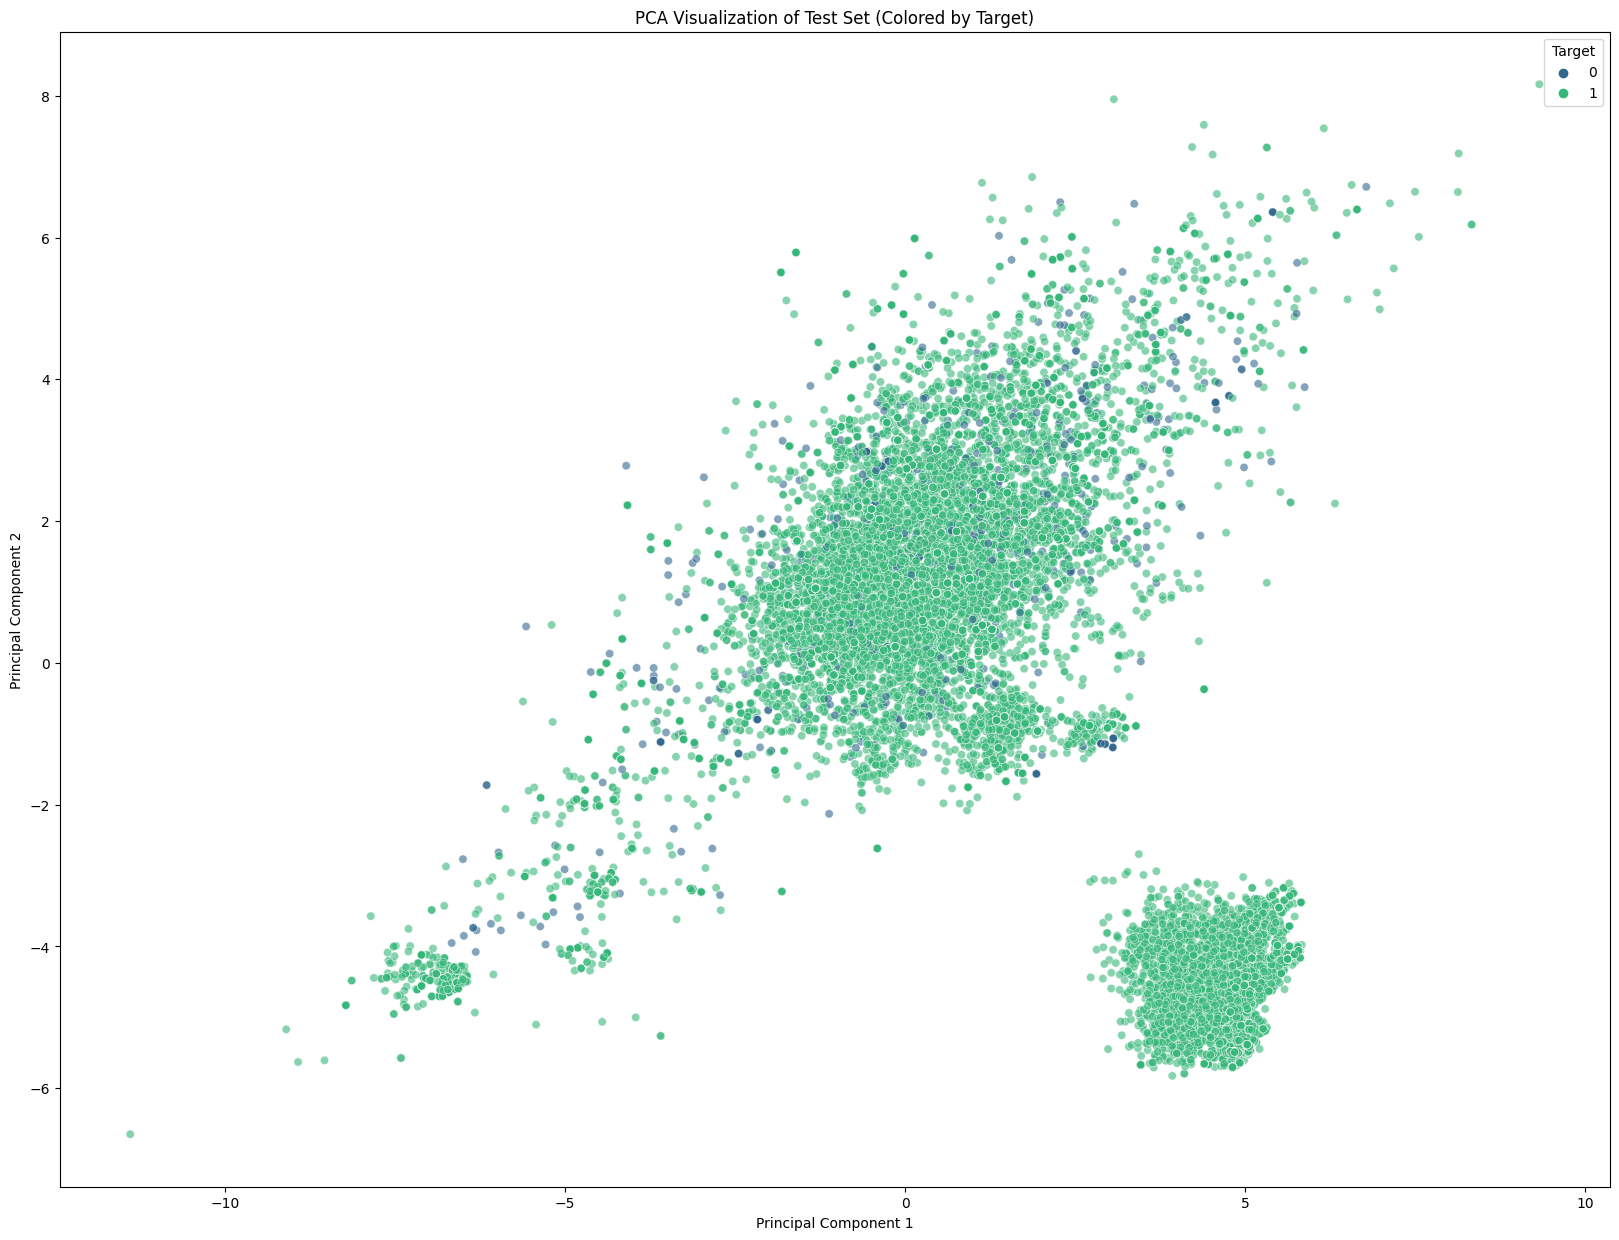

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization after PCA**

The scatter plot of the PCA-transformed training data (PC1 vs. PC2) provides the first interpretable view of the feature space.

- Observation: The plot shows a clear and overwhelming concentration of the majority class (malware) samples. The minority class (benign) appears as a small, scattered cluster or dispersed points, confirming the severe class imbalance is still evident in the projected 2D space.
- Implication: Although the data is projected to 2D, the two classes appear to be highly overlapping, suggesting that a simple linear decision boundary (which the Perceptron is limited to) may struggle to perfectly separate the two classes, even in this reduced space. This visualization strongly justifies the need for oversampling.

**Oversampling (SMOTE)**

The severe class imbalance (97.57% malware) must be addressed to train a meaningful classifier. Synthetic Minority Over-sampling Technique (SMOTE) is employed for this purpose.
- Process: SMOTE generates synthetic instances for the minority class (benign). It works by selecting minority samples and creating new samples along the line segments connecting the minority sample to its nearest neighbors.
- Application Constraint: SMOTE is applied exclusively to the training data (`X_train, y_train`) after the PCA reduction. Applying it to the test set would invalidate the final performance assessment.

In [20]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
x_train, y_train = smote.fit_resample(x_train, y_train)
# Print the shapes of the original and resampled data to see the effect
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

**Result**

The application of SMOTE successfully balances the training dataset, resulting in 68,494 samples with an equal 50.0% distribution for both the malware and benign classes.

**After Oversampling Visualization**

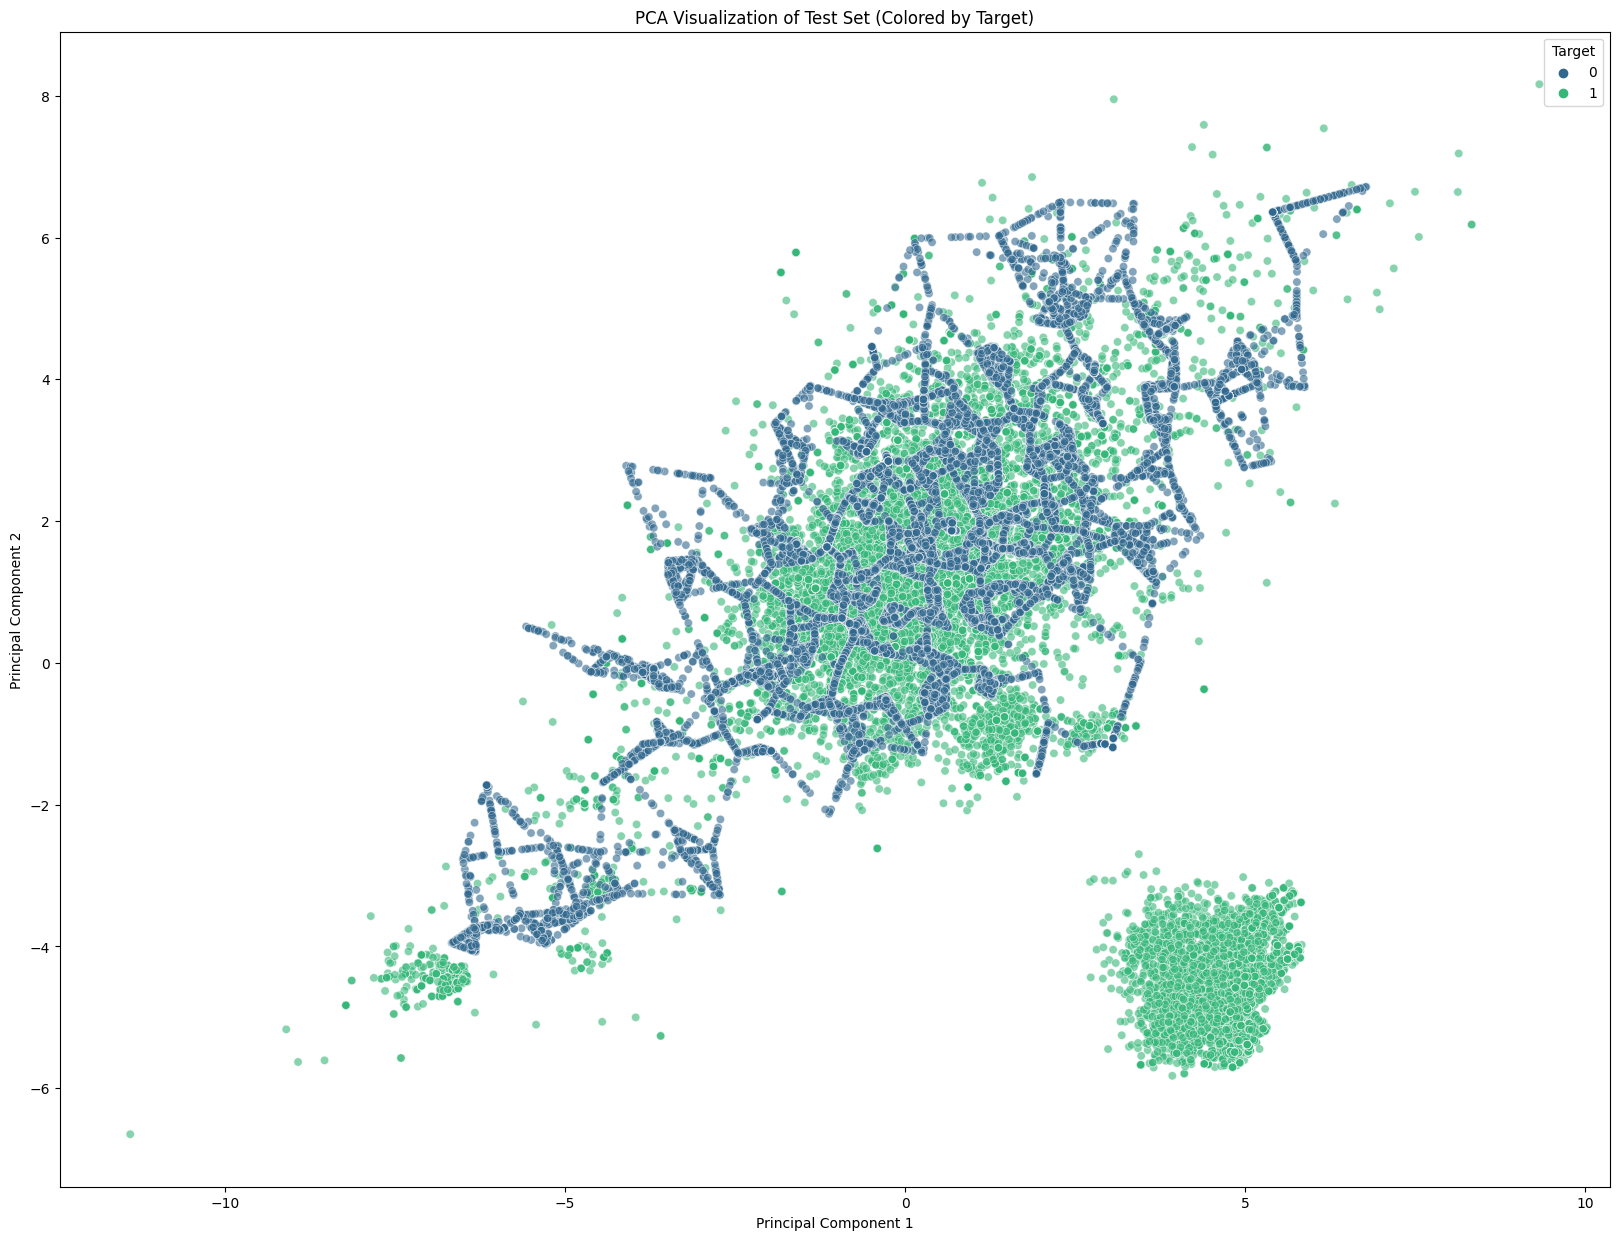

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization after SMOTE**

The second scatter plot displays the data after SMOTE has been applied to the training set.

- Observation: The plot shows a significant increase in the density of the minority class samples (Class 0). The synthetic samples fill the sparsely populated regions, making the two classes appear much more equally represented across the 2D space.
- Benefit: This balanced distribution ensures that the Perceptron, during its training phase, receives sufficient examples of the minority class, preventing the model from becoming heavily biased toward simply predicting the majority class. The objective for the subsequent training is to allow the Perceptron to learn a generalizable linear boundary that respects the presence of both classes.

# Model Training and Experiments

## Model Architecture, Model Building, and Model Training (PyTorch)

**The Perceptron Model Structure**

The Perceptron, in its modern usage for binary classification, represents the simplest form of an artificial neural network. In PyTorch, this model is built by inheriting from the nn.Module base class.
- Linear Layer: The core of the Perceptron is the single linear transformation, implemented via nn.Linear(input_dim, 1). This layer performs the weighted sum of the input features ($\mathbf{X}$) and adds a bias term ($b$). The mathematical operation is represented as $z = \mathbf{W} \cdot \mathbf{X} + b$. The weights ($\mathbf{W}$) and bias ($b$) are the learnable parameters of the model.
- Activation Function: For a binary classification task, the raw output ($z$) of the linear layer must be converted into a probability. The Sigmoid activation function (nn.Sigmoid()) is used to map $z$ to a value between 0 and 1. This output, $\hat{y}$, represents the probability of the input belonging to the positive class. The use of a differentiable activation function is crucial, as it allows for the calculation of gradients necessary for the backpropagation algorithm. 

**The Training Process**

Training a Perceptron in PyTorch involves a standardized loop to iteratively adjust the weights and bias to minimize the classification error.
- Forward Pass: The input data is passed sequentially through the linear layer and the sigmoid activation to produce the predicted probabilities ($\hat{y}$).
- Loss Calculation: A Loss Function measures the discrepancy between the predicted probabilities ($\hat{y}$) and the true binary labels ($y$). For models with a Sigmoid output, the standard choice is the Binary Cross-Entropy (BCE) Loss. Minimizing the BCE loss is equivalent to maximizing the likelihood of observing the true labels given the model's parameters.
- Backward Pass (Backpropagation): The gradient of the loss with respect to every weight and bias parameter is calculated. This is achieved through the backpropagation algorithm, which efficiently propagates the error signal backward through the network layers, governed by the chain rule of calculus. 
- Parameter Update (Optimization): An Optimizer uses the calculated gradients to update the parameters, moving them in the direction that decreases the loss function.

**Key Hyperparameters and Their Roles**

Hyperparameters are external settings whose values are set prior to the start of the learning process and significantly influence training performance and model generalization.
- Learning Rate ($\eta$): Controls the step size taken during the parameter updates in the direction of the loss gradient. A high learning rate can cause the optimization to overshoot the minimum loss, leading to oscillations. A low rate can result in slow convergence.
- Optimizer: The algorithm responsible for adjusting the weights based on the calculated gradients (e.g., Adam, SGD). Adam is often preferred as it adapts the learning rate for each parameter, providing fast and stable convergence across various data types.
- Epochs: Defines the number of full cycles over the entire training dataset. A sufficient number of epochs is necessary for convergence, but too many can lead to overfitting if not managed by regularization techniques.
- Batch Size: The number of samples processed before the model's parameters are updated. For this small Perceptron trained on the entire resampled dataset, the full batch size is effectively used per epoch.
- Early Stopping Patience: A counter specifying the number of consecutive epochs allowed without improvement in the validation loss. If this threshold is reached, training terminates early to prevent the model from overfitting to the training data.

**Implementation**

**Model Architecture**

The implemented model is a Perceptron, which is the simplest form of a neural network, capable of performing linear binary classification.
- Structure: The model consists of a single linear layer, transforming the input features ($\mathbf{X}$, which are 2 Principal Components after dimensionality reduction) into a single scalar output. The model summary confirms the input dimension is 2, resulting in only 3 trainable parameters: two weights ($w_1, w_2$) and one bias term ($b$).
- Activation Function: The output of the linear transformation is passed through the Sigmoid function ($\sigma(z) = \frac{1}{1 + e^{-z}}$). This activation squashes the output value to a range between 0 and 1, allowing the result to be interpreted as the probability of the input belonging to the positive class (malware). 

**Training Dynamics and Optimization**

Training the Perceptron involves iteratively minimizing the difference between the model's predictions and the true labels across the epochs.

- Loss Function: Binary Cross-Entropy (BCE) Loss is employed. For binary classification, BCE measures the performance of a classification model whose output is a probability value between 0 and 1. The goal of training is to minimize this loss, thereby increasing the model's confidence in the correct class.
- Optimizer and Learning: The Adam optimizer is used to adjust the model's weights and bias. This is an adaptive learning rate optimization algorithm that computes individual learning rates for different parameters. The backward pass utilizes the backpropagation algorithm, which calculates the gradient of the loss function with respect to every parameter in the network, providing the direction and magnitude for the parameter updates performed by the optimizer.
- Early Stopping: This mechanism is a regularization technique designed to prevent overfitting. The training process monitors the validation loss, and if it fails to improve for a predefined number of epochs (`patience=8`), training is halted. This ensures that the final model state captures the best generalization capability observed during the training process.

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tensor, y_train_tensor, test_size=0.2, random_state=42
)

train_loss_history = []
val_loss_history = []
train_accuracy_history = []
val_accuracy_history = []

class PerceptronModel(nn.Module):
    def __init__(self, input_dim):
        super(PerceptronModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

input_dim = x_train.shape[1]
model = PerceptronModel(input_dim)

print("\n--- Model Architecture ---")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

early_stopping_patience = 8
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

epochs = 100
print("\n--- Training Model ---")
for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()

    outputs = model(x_train_split)
    loss = criterion(outputs, y_train_split.view_as(outputs))

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val_split)
        val_loss = criterion(val_outputs, y_val_split.view_as(val_outputs))

        train_preds_for_acc = (outputs > 0.5).float()
        train_accuracy = (train_preds_for_acc == y_train_split).float().mean()

        val_preds = (val_outputs > 0.5).float()
        val_accuracy = (val_preds == y_val_split).float().mean()

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())
    train_accuracy_history.append(train_accuracy.item())
    val_accuracy_history.append(val_accuracy.item())

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {loss.item():.4f}, "
          f"Train Accuracy: {train_accuracy.item():.4f}, "
          f"Validation Loss: {val_loss.item():.4f}, "
          f"Validation Accuracy: {val_accuracy.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_model_state)
            break

print("\nTraining complete.")


--- Model Architecture ---
PerceptronModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Number of trainable parameters: 3

--- Training Model ---
Epoch 1/100, Train Loss: 1.2739, Train Accuracy: 0.4998, Validation Loss: 1.2356, Validation Accuracy: 0.5008
Epoch 2/100, Train Loss: 1.2606, Train Accuracy: 0.4998, Validation Loss: 1.2229, Validation Accuracy: 0.5008
Epoch 3/100, Train Loss: 1.2474, Train Accuracy: 0.4998, Validation Loss: 1.2104, Validation Accuracy: 0.5008
Epoch 4/100, Train Loss: 1.2344, Train Accuracy: 0.4998, Validation Loss: 1.1979, Validation Accuracy: 0.5008
Epoch 5/100, Train Loss: 1.2214, Train Accuracy: 0.4998, Validation Loss: 1.1857, Validation Accuracy: 0.5008
Epoch 6/100, Train Loss: 1.2087, Train Accuracy: 0.4998, Validation Loss: 1.1735, Validation Accuracy: 0.5008
Epoch 7/100, Train Loss: 1.1960, Train Accuracy: 0.4998, Validation Loss: 1.1615, Validation Accuracy: 0.5007
Epoch 8/100, Train Loss: 1.1835, Train Ac

**Model Validation and Training History**

Final Training Loss (evaluated on full x_train): 0.6678
Final Training Accuracy (evaluated on full x_train): 0.5000

Learned Weights: [-0.0699242  -0.10982167]
Learned Bias: 0.0712

Sample Predictions (from training data):
  Input: [-8.22433293 -4.82968481], Actual: 1, Predicted (proba): 0.7643, Predicted (binary): 1
  Input: [-0.12432182  0.88072607], Actual: 1, Predicted (proba): 0.4958, Predicted (binary): 0
  Input: [-8.22433293 -4.82968481], Actual: 1, Predicted (proba): 0.7643, Predicted (binary): 1
  Input: [-0.15724425  0.2781775 ], Actual: 1, Predicted (proba): 0.5129, Predicted (binary): 1
  Input: [-1.31936251  1.05192543], Actual: 1, Predicted (proba): 0.5120, Predicted (binary): 1
  Input: [1.57739163 3.20050812], Actual: 1, Predicted (proba): 0.4036, Predicted (binary): 0
  Input: [0.78755629 3.21830904], Actual: 1, Predicted (proba): 0.4165, Predicted (binary): 0
  Input: [1.85246966 3.80433942], Actual: 1, Predicted (proba): 0.3832, Predicted (binary): 0
  Input: [0.055

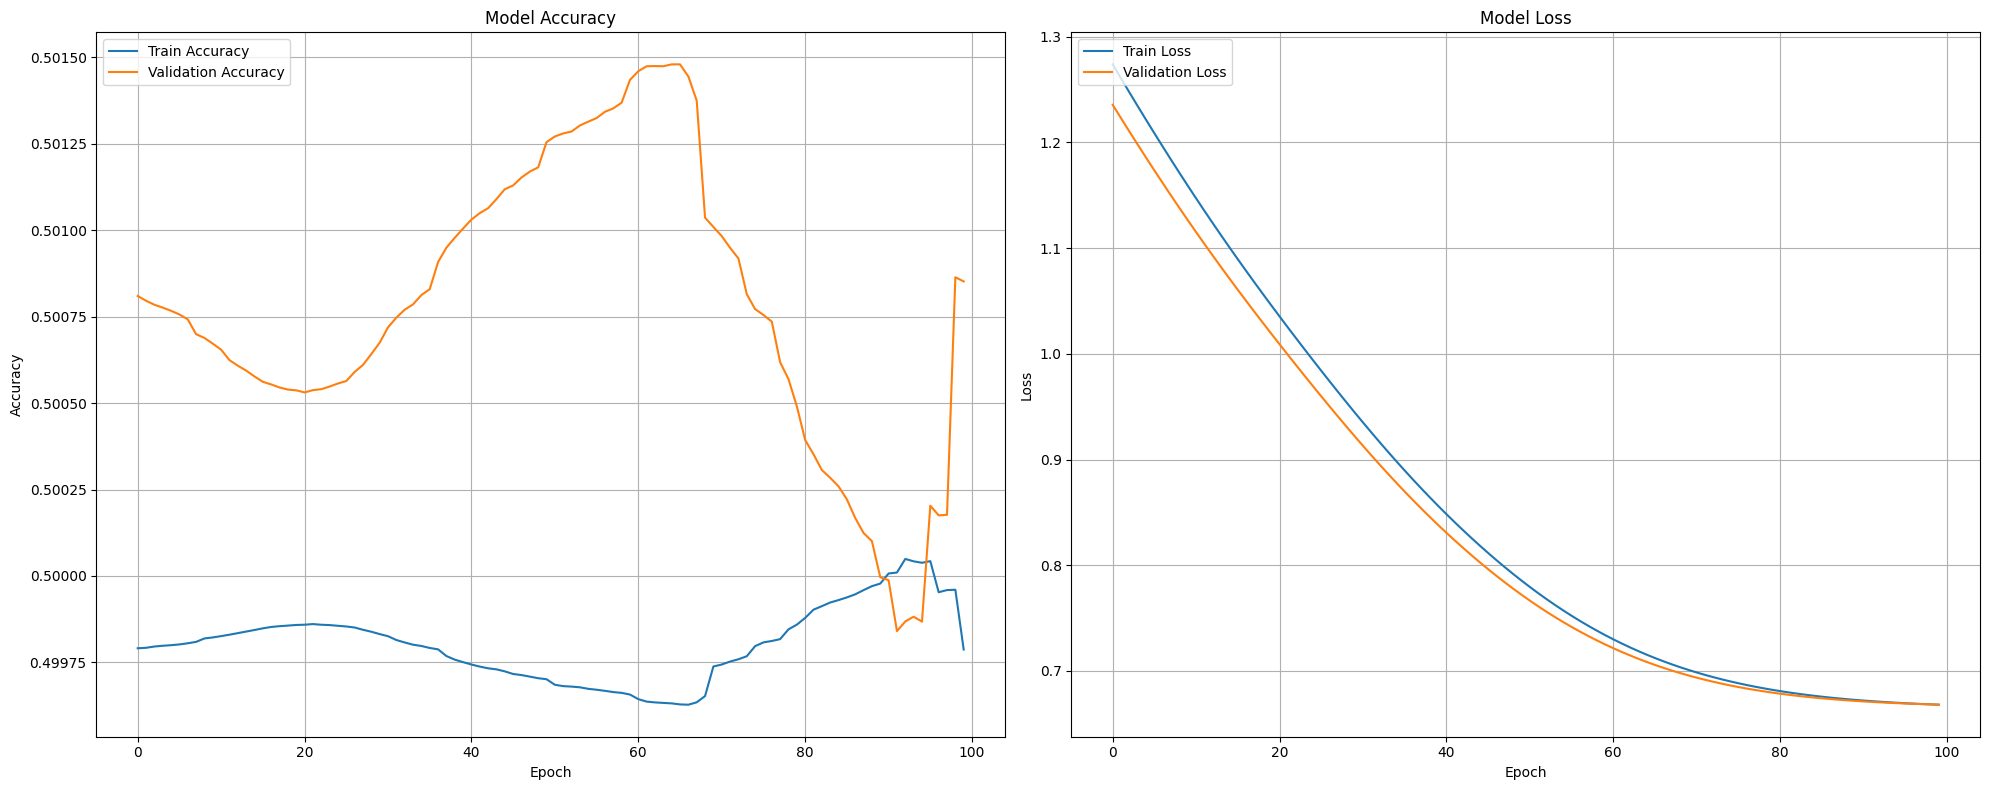

In [ ]:
model.eval()
with torch.no_grad():
    outputs_train_eval = model(x_train_tensor)
    loss_train_eval = criterion(outputs_train_eval, y_train_tensor.view_as(outputs_train_eval))
    
    predictions_train_eval = (outputs_train_eval > 0.5).float()
    
    accuracy_train_eval = (predictions_train_eval == y_train_tensor).float().mean()

print(f"Final Training Loss (evaluated on full x_train): {loss_train_eval.item():.4f}")
print(f"Final Training Accuracy (evaluated on full x_train): {accuracy_train_eval.item():.4f}")

weights = model.linear.weight.data.cpu().numpy()
bias = model.linear.bias.data.cpu().numpy()
print(f"\nLearned Weights: {weights.flatten()}")
print(f"Learned Bias: {bias[0]:.4f}")

model.eval()
with torch.no_grad():
    y_pred_proba_tensor = model(x_train_tensor)
y_pred_proba = y_pred_proba_tensor.cpu().numpy().flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nSample Predictions (from training data):")
for i in range(min(10, len(x_train))):
    print(f"  Input: {x_train[i]}, Actual: {y_train[i]}, Predicted (proba): {y_pred_proba[i]:.4f}, Predicted (binary): {y_pred[i]}")

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.plot(train_accuracy_history, label='Train Accuracy')
plt.plot(val_accuracy_history, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Decision Boundary**

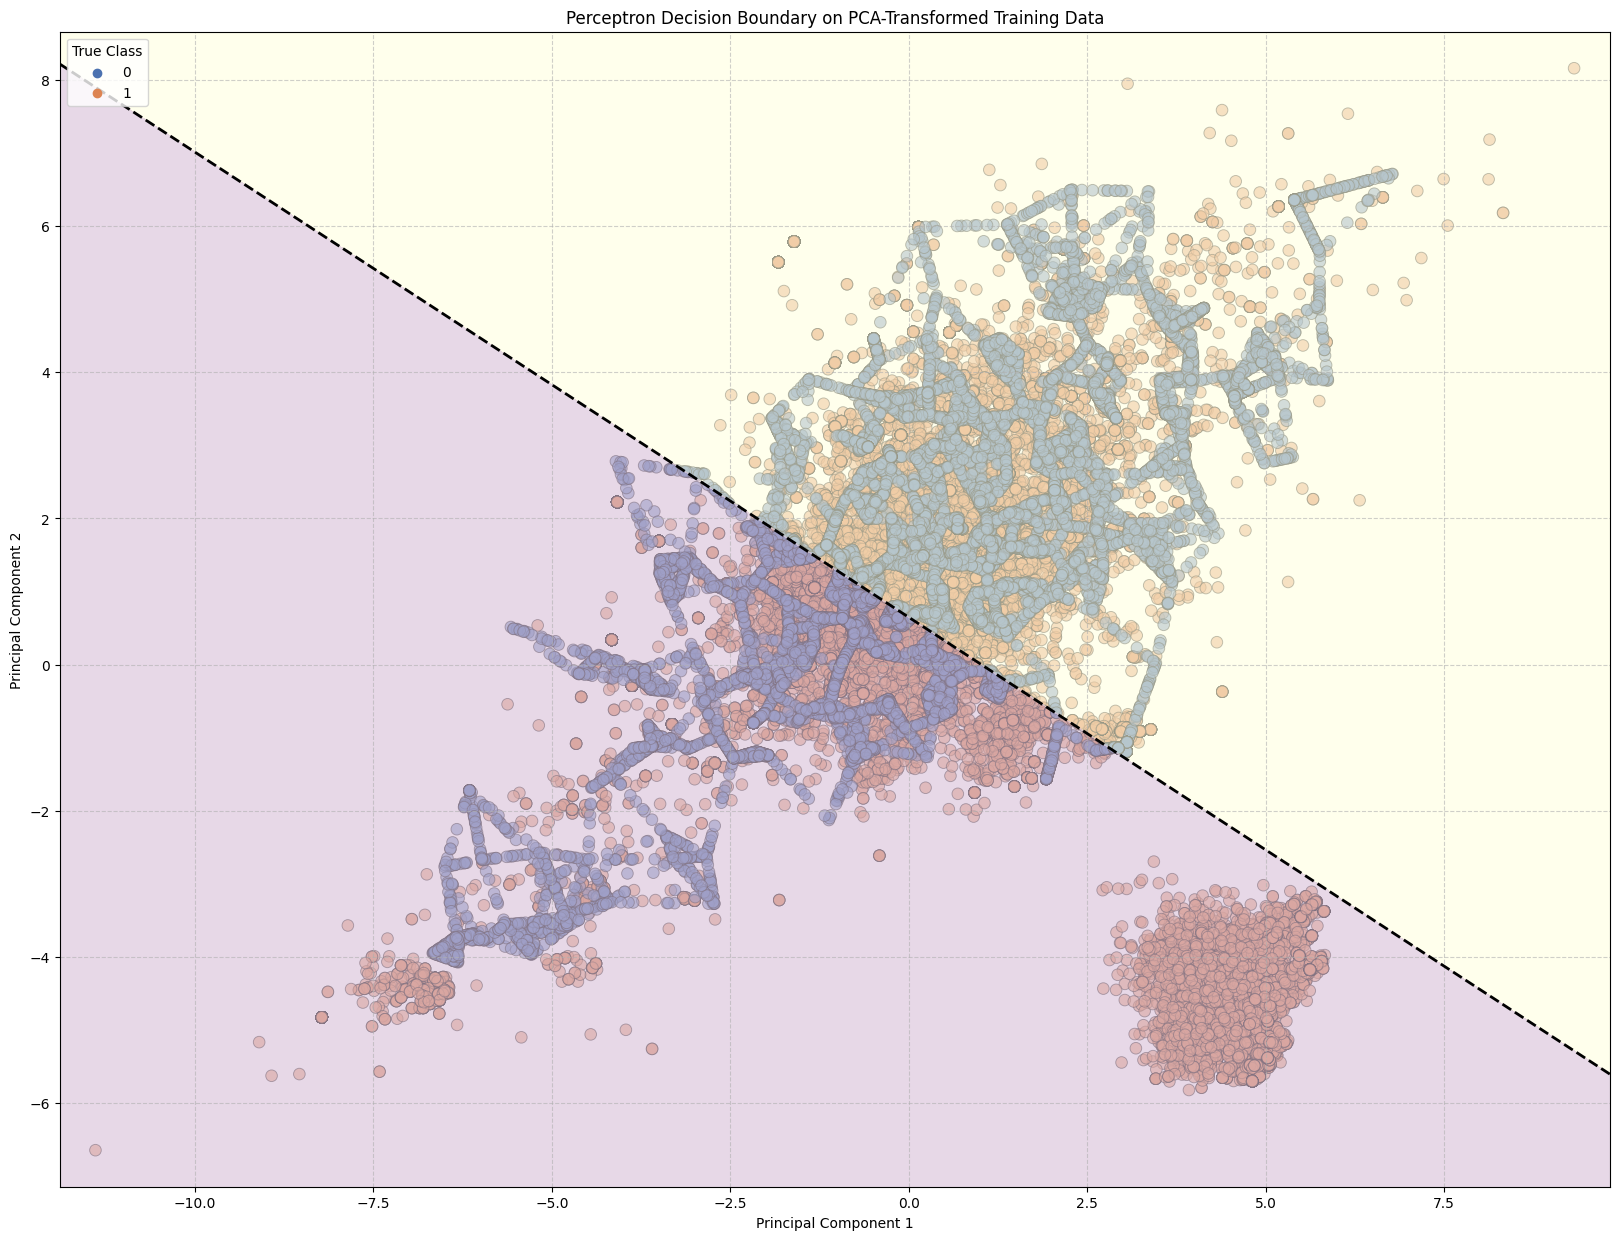

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor = torch.tensor(meshgrid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_proba_tensor = model(meshgrid_tensor)
Z_proba = Z_proba_tensor.cpu().numpy().reshape(xx.shape)

colors_contourf = ['#FFFFE0', '#D8BFD8']
cmap_custom = plt.matplotlib.colors.ListedColormap(colors_contourf)

plt.contourf(xx, yy, Z_proba, levels=[0, 0.5, 1], alpha=0.6, cmap=cmap_custom)
plt.contour(xx, yy, Z_proba, levels=[0.5], colors='k', linestyles='--', linewidths=2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Model Evaluation

**Classification Metrics**

Evaluating a classification model involves assessing its performance using metrics derived from the Confusion Matrix. This matrix is the fundamental tool for evaluating binary classification, comparing the predicted class labels against the true class labels.

- Accuracy: The ratio of correctly classified instances (TP + TN) to the total number of instances. It represents the overall effectiveness of the model.
- Precision: Of all instances predicted as positive, the fraction that were truly positive. It measures the quality of positive predictions.
- Recall (Sensitivity): Of all actual positive instances, the fraction that was correctly identified. It measures the completeness of positive predictions.
- F1-Score: The harmonic mean of Precision and Recall. It provides a single metric that balances both measures.
- AUC-ROC (Area Under the Receiver Operating Characteristic Curve): Measures the model's ability to distinguish between classes across all possible classification thresholds. An AUC of 0.5 indicates performance equivalent to random guessing, while 1.0 is perfect discrimination.

**Confusion Matrix**

Confusion Matrix Components:

- True Positives (TP): Instances correctly predicted as positive (Class 1).
- True Negatives (TN): Instances correctly predicted as negative (Class 0).
- False Positives (FP) (Type I Error): Instances incorrectly predicted as positive when they are actually negative.
- False Negatives (FN) (Type II Error): Instances incorrectly predicted as negative when they are actually positive.

**Classification Reports**

In [ ]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_pred_proba_test_tensor = model(x_test_tensor)
y_pred_proba_test = y_pred_proba_test_tensor.cpu().numpy().flatten()
y_pred_test = (y_pred_proba_test > 0.5).astype(int)

y_test_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else y_test.values if isinstance(y_test, pd.Series) else y_test

cm = confusion_matrix(y_test_np, y_pred_test)
accuracy = accuracy_score(y_test_np, y_pred_test)
precision = precision_score(y_test_np, y_pred_test, average='macro', zero_division=1)
recall = recall_score(y_test_np, y_pred_test, average='macro', zero_division=1)
f1 = f1_score(y_test_np, y_pred_test, average='macro', zero_division=1)

roc_auc = roc_auc_score(y_test_np, y_pred_proba_test)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_test, zero_division=1))

Confusion Matrix:
[[ 186   40]
 [3873 4677]]
Accuracy: 0.554
Precision: 0.519
Recall: 0.685
F1-score: 0.396
AUC-ROC: 0.639

Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.82      0.09       226
           1       0.99      0.55      0.71      8550

    accuracy                           0.55      8776
   macro avg       0.52      0.69      0.40      8776
weighted avg       0.97      0.55      0.69      8776



**Interpretation of Performance Statistics**

The test results indicate a significant class imbalance in the test data, where Class 1 (support: 8550) heavily outweighs Class 0 (support: 226).

- Accuracy (0.554): The raw accuracy is misleading due to the severe imbalance. Since 97.4% of the data belongs to Class 1, simply predicting Class 1 almost always yields a high number of correct predictions (TN).

Classification Report (Macro Averaging):

- Class 1 (Majority): High Precision (0.99) but low Recall (0.55). The model is extremely reliable when it predicts Class 1, but it misses nearly half of the actual Class 1 instances (high FN count).
- Class 0 (Minority): Extremely low Precision (0.05) but high Recall (0.82). The model correctly identifies most true Class 0 instances (high recall), but nearly all its predictions for Class 0 are wrong (low precision, 186/226 instances are TN). This severe imbalance in performance suggests the Perceptron struggles to correctly identify the boundary for the minority class in the presence of noise.
- Macro F1-Score (0.396): This low balanced score confirms that the model's overall discriminatory power is poor, particularly because the low precision of Class 0 heavily penalizes the macro average.

**Confusion Matrix**

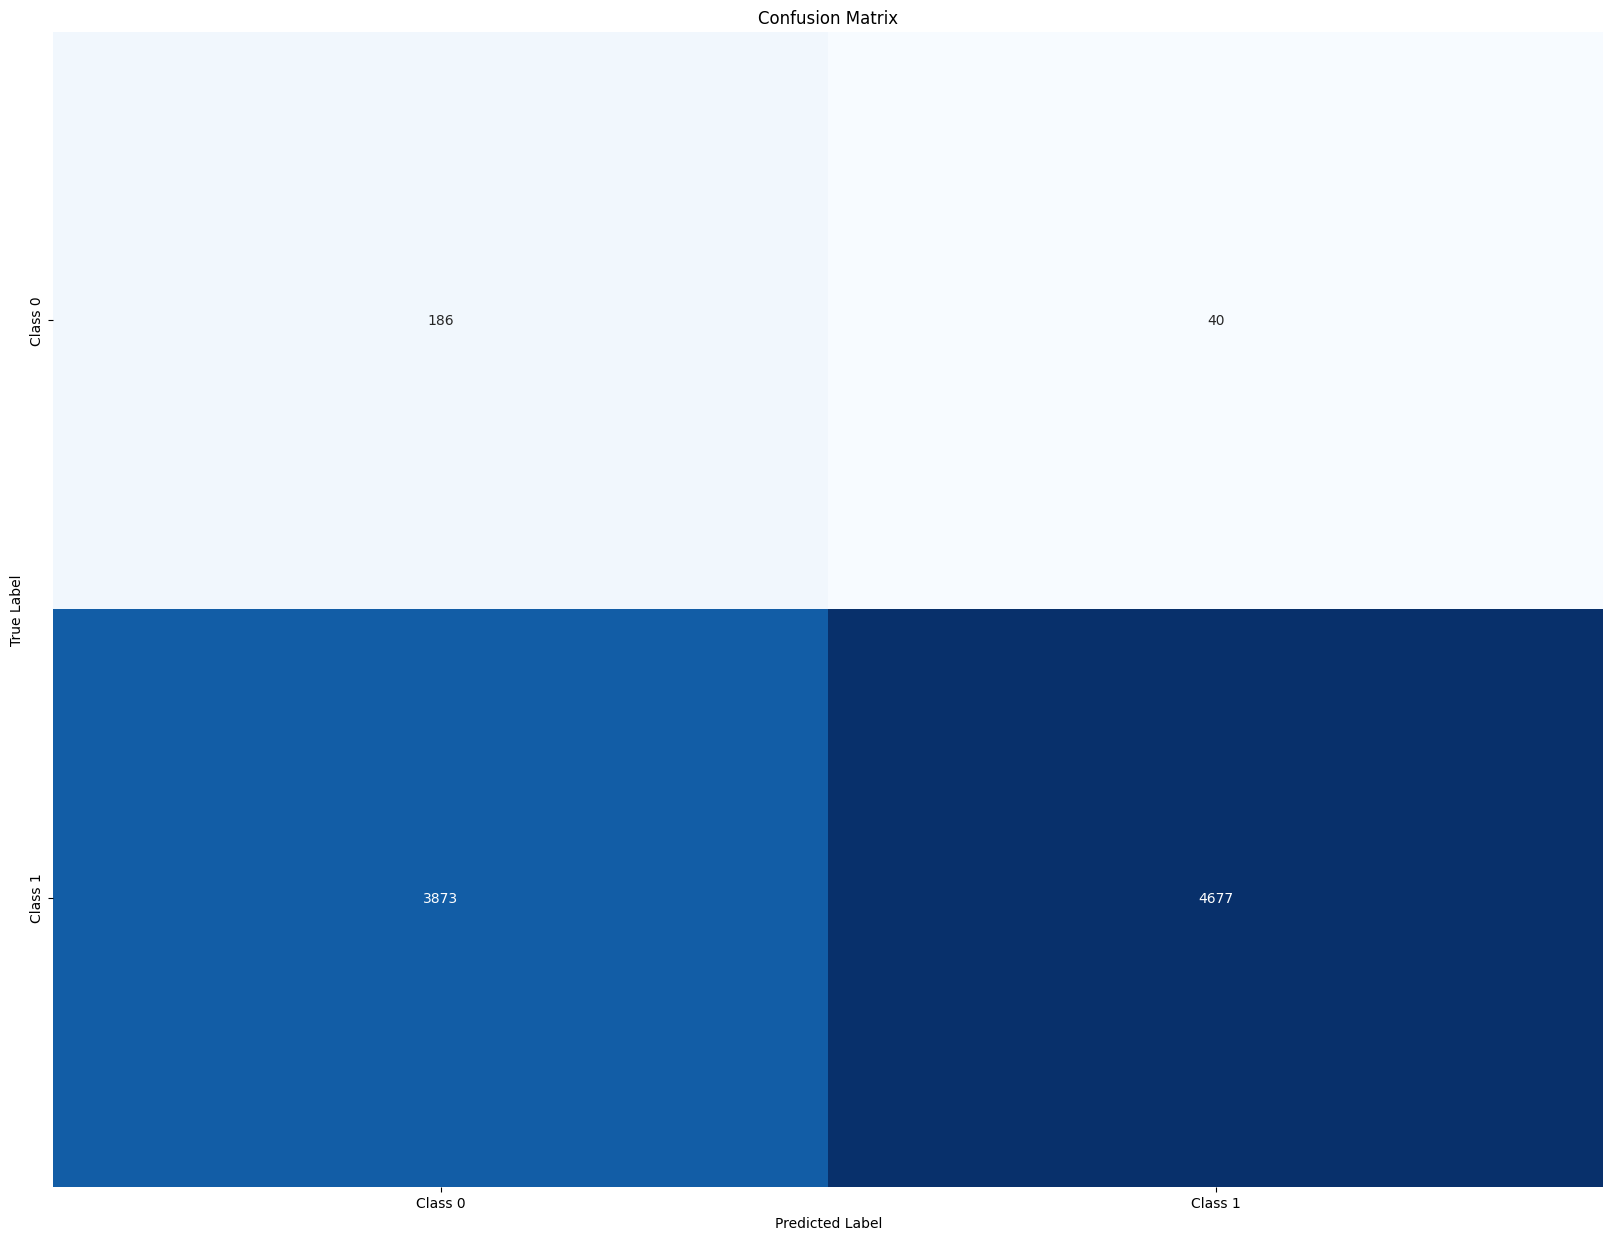

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Confusion Matrix Analysis:**

The model achieves a very high number of True Positives (4677) but also a massive number of False Negatives (3873) for the majority Class 1. For the minority Class 0, the model achieves a decent True Negative count (186) but generates 40 False Positives.

**Precision-Recall Curve**


--- Plotting Precision-Recall Curve ---


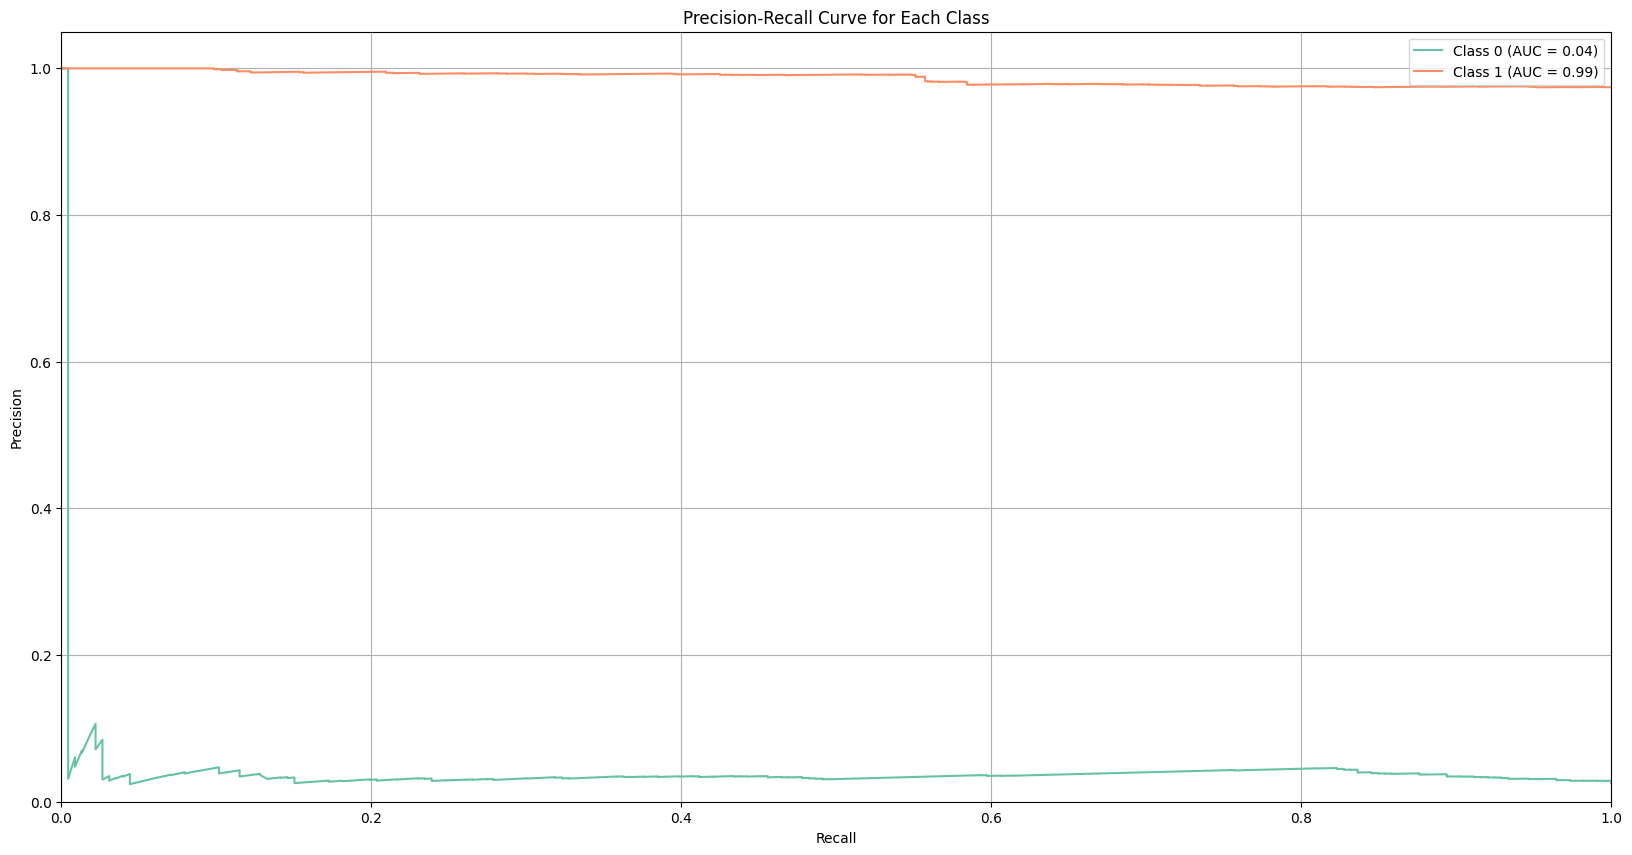

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

class_labels = ["0", "1"]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

y_pred_proba_test_pr = y_pred_proba_test

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test_np == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = y_pred_proba_test_pr
    else:
        y_pred_score = 1 - y_pred_proba_test_pr

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

The Precision-Recall (PR) curves, which are generally more informative than ROC curves for imbalanced datasets, confirm the poor classification capability.

- Class 1 (Majority): The PR curve starts high (near 1.0) and stays relatively high, reflecting the fact that the vast majority of the data is Class 1, making high precision easier to achieve, especially at low recall levels.
- Class 0 (Minority): The PR curve for Class 0 is extremely low and follows the axes closely. The Area Under the Curve (AUC) for Class 0 is very small, indicating that maintaining high precision while increasing recall for this minority class is almost impossible for the current model.

**ROC-AUC Curve**

The ROC curves plot the True Positive Rate (Recall) against the False Positive Rate across all thresholds.


--- Plot ROC Curve for Label 0 and 1 ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

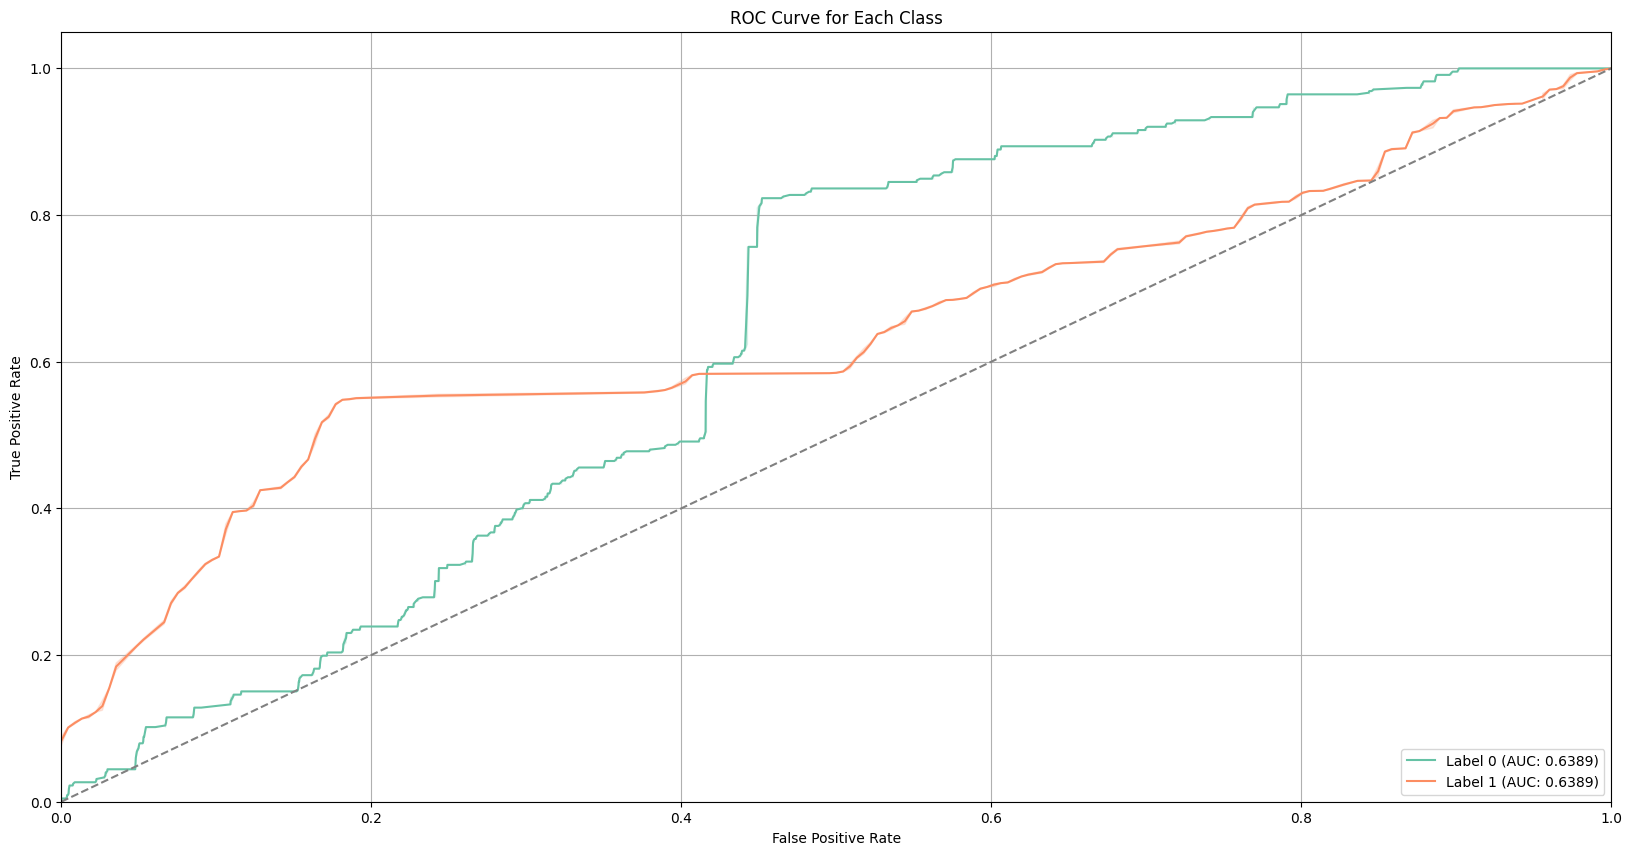


--- AUC ROC Values per Class ---
Label 0 AUC: 0.6389
Label 1 AUC: 0.6389
------------------------------


In [ ]:
print("\n--- Plot ROC Curve for Label 0 and 1 ---")

x_test_tensor_roc = torch.tensor(x_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_pred_proba_roc_tensor = model(x_test_tensor_roc)
y_pred_proba_roc = y_pred_proba_roc_tensor.cpu().numpy().flatten()

class_labels_roc = ["Label 0", "Label 1"]
classes_roc = [0, 1]

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_val in enumerate(classes_roc):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test_np, y_pred_proba_roc)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test_np, 1 - y_pred_proba_roc)

    roc_auc_per_class[class_val] = auc(fpr[class_val], tpr[class_val])

    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels_roc[i]} (AUC: {roc_auc_per_class[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("\n--- AUC ROC Values per Class ---")
for class_val in classes_roc:
    print(f"{class_labels_roc[class_val]} AUC: {roc_auc_per_class[class_val]:.4f}")
print("-" * 30)

- Overall Performance: The AUC for both classes is identical at 0.6389. This value is marginally better than random guessing (0.5), suggesting that the model has slight discriminatory power but is fundamentally weak.
- Visualization: The curve lies close to the diagonal random line, visually confirming the low discriminatory capability. The model fails to achieve a high True Positive Rate without also incurring a high False Positive Rate, which is characteristic of a poor classifier.

**Decision Boundary (Test Dataset)**

The visualization of the test data against the learned linear decision boundary is consistent with the numerical metrics.

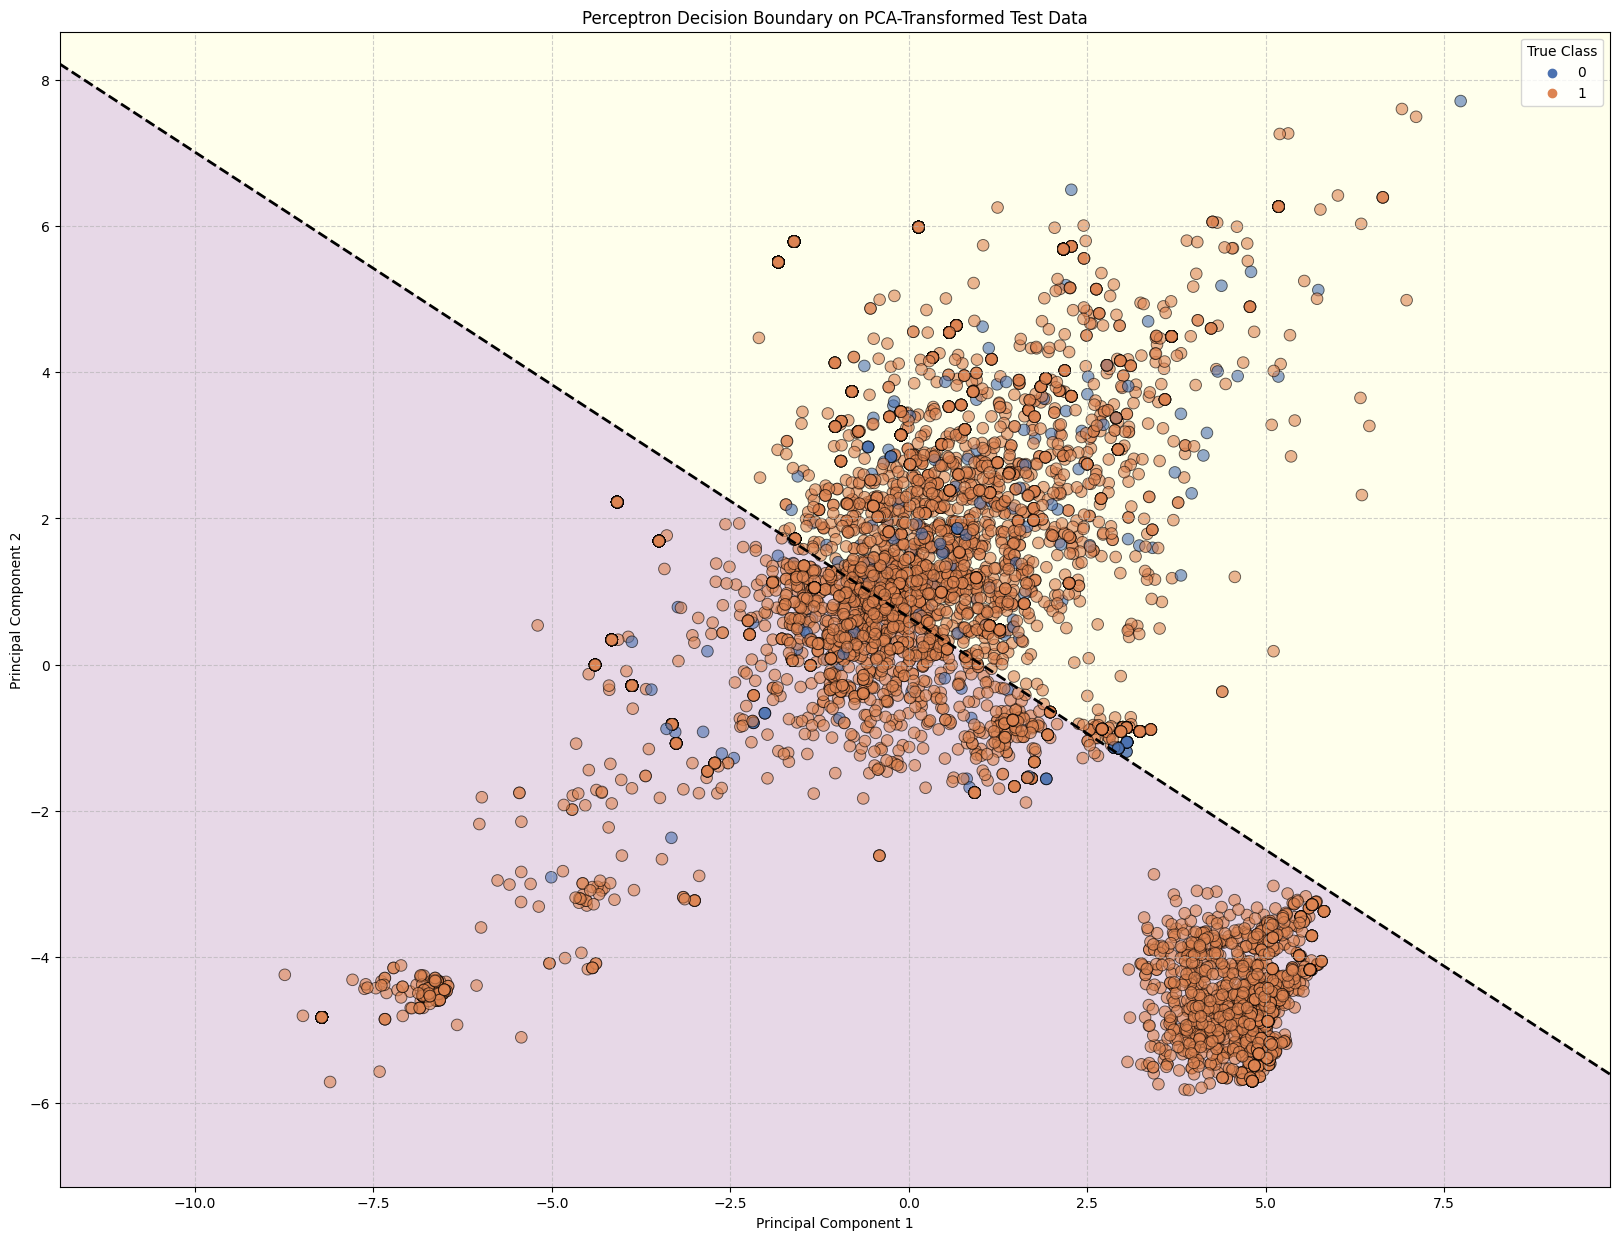

In [ ]:
plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test_np
})

plt.figure(figsize=(20, 15))

meshgrid_points_test = np.c_[xx.ravel(), yy.ravel()]
meshgrid_tensor_test = torch.tensor(meshgrid_points_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    Z_proba_tensor_test = model(meshgrid_tensor_test)
Z_proba_test = Z_proba_tensor_test.cpu().numpy().reshape(xx.shape)

colors_contourf_test = ['#FFFFE0', '#D8BFD8']
cmap_custom_test = plt.matplotlib.colors.ListedColormap(colors_contourf_test)

plt.contourf(xx, yy, Z_proba_test, levels=[0, 0.5, 1], alpha=0.6, cmap=cmap_custom_test)
plt.contour(xx, yy, Z_proba_test, levels=[0.5], colors='k', linestyles='--', linewidths=2)

sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Test Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Visualization Interpretation**

- Non-Separability: The linear decision boundary cuts directly through the highly intermixed clusters of Class 0 (light dots) and Class 1 (dark dots).
- Misclassification: The plot visually demonstrates the high misclassification rate, showing that many data points from both classes are located on the wrong side of the linear boundary. The classes are not linearly separable in the 2D PCA space, meaning the simple Perceptron cannot find a globally optimal line to differentiate between the two groups. The model’s failure is rooted in its inability to learn non-linear decision rules required by the complex, overlapping distribution of the features.

# Conclusion

This project serves as a comprehensive educational bridge between foundational machine learning and advanced deep learning frameworks. By implementing the Perceptron in PyTorch with a manual training loop, the fundamental mechanics of neural networks are exposed, including the explicit control over gradients and parameter updates. The use of PCA and SMOTE highlights practical data science challenges (dimensionality and imbalance) and how simple models address them. This hands-on approach provides a deep and clear understanding of how even a single neuron learns a linear boundary through optimization.

# References

- [Perceptron Research](https://www.researchgate.net/publication/300873533_Perceptrons)
- [MLP PyTorch](https://docs.pytorch.org/vision/main/generated/torchvision.ops.MLP.html)
- [Building Multilayer Perceptron Models in PyTorch](https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/)
- [What is Perceptron | The Simplest Artificial neural network](https://www.geeksforgeeks.org/machine-learning/what-is-perceptron-the-simplest-artificial-neural-network/)
- [Learning PyTorch with Examples](https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html)